# Online Payments Fraud Detection
**Dataset:** [Online Payments Fraud Detection Dataset](https://www.kaggle.com/datasets/rupakroy/online-payments-fraud-detection-dataset)

This notebook covers data cleaning and exploratory analysis on a fraud detection dataset. The idea is to understand the data well enough to know what we're working with before jumping into modeling.

Online payment fraud is a major issue in the financial sector. Before building any machine learning model to detect fraud, it is important to first understand the dataset. In this notebook, we perform data cleaning and exploratory data analysis (EDA) to examine the structure, quality, and key characteristics of the data.

## Notebook Structure
1. Imports & Setup
2. Load the Data
3. Initial Exploration
4. Data Cleaning
5. Exploratory Data Analysis
6. Key Insights

## 1. Imports & Setup
Importing the usual libraries and downloading the dataset from Kaggle.

In [1]:
!pip install kagglehub

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import kagglehub


# Plotting style
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.titlesize'] = 14

import warnings
warnings.filterwarnings('ignore')
path = kagglehub.dataset_download("rupakroy/online-payments-fraud-detection-dataset")

print("Path to dataset files:", path)

print('All libraries imported successfully.')

Using Colab cache for faster access to the 'online-payments-fraud-detection-dataset' dataset.
Path to dataset files: /kaggle/input/online-payments-fraud-detection-dataset
All libraries imported successfully.



## 2. Load the Data



In [3]:
import os

# Find the CSV file inside the downloaded path
csv_file = None
for root, dirs, files in os.walk(path):
    for f in files:
        if f.endswith('.csv'):
            csv_file = os.path.join(root, f)
            break


print("CSV found at:", csv_file)  #path

df = pd.read_csv(csv_file)
print(f'Dataset loaded: {df.shape[0]:,} rows × {df.shape[1]} columns')


df.head()

CSV found at: /kaggle/input/online-payments-fraud-detection-dataset/PS_20174392719_1491204439457_log.csv
Dataset loaded: 6,362,620 rows × 11 columns


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


## 3. Initial Exploration

To understand the basic structure of the dataset we examine:

- The number of rows and columns
- The names of the features
- Data types of each column
- Basic statistical summaries

This step helps identify potential issues such as incorrect data types, missing values, or unusual distributions that may require cleaning.

In [4]:
# Shape
print(f'Shape: {df.shape}')

# Column names and dtypes
print('\nColumn Info:')
df.info()
df.columns

Shape: (6362620, 11)

Column Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            object 
 2   amount          float64
 3   nameOrig        object 
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        object 
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), object(3)
memory usage: 534.0+ MB


Index(['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig',
       'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud',
       'isFlaggedFraud'],
      dtype='object')

### Statistical Summary

We compute descriptive statistics for the numerical columns to understand the general distribution of values in the dataset. 

These statistics include measures such as the mean, median, minimum, maximum, and standard deviation. This helps us detect extreme values and understand the overall scale of the data.

In [5]:
# Statistical summary of numerical columns
df.describe()

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
count,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06
mean,2.433972e+02,1.798619e+05,8.338831e+05,8.551137e+05,1.100702e+06,1.224996e+06,1.290820e-03,2.514687e-06
std,1.423320e+02,6.038582e+05,2.888243e+06,2.924049e+06,3.399180e+06,3.674129e+06,3.590480e-02,1.585775e-03
min,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.560000e+02,1.338957e+04,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,2.390000e+02,7.487194e+04,1.420800e+04,0.000000e+00,1.327057e+05,2.146614e+05,0.000000e+00,0.000000e+00
75%,3.350000e+02,2.087215e+05,1.073152e+05,1.442584e+05,9.430367e+05,1.111909e+06,0.000000e+00,0.000000e+00
max,7.430000e+02,9.244552e+07,5.958504e+07,4.958504e+07,3.560159e+08,3.561793e+08,1.000000e+00,1.000000e+00


### Unique Values

We examine the unique values present in categorical columns. This allows us to understand the possible categories within the dataset and verify that they match the expected transaction types.

Checking unique values can also help identify potential data entry inconsistencies.

In [6]:
# Check unique values in categorical columns
for col in df.select_dtypes(include='object').columns:
    print(f'{col}: {df[col].nunique()} unique values → {df[col].unique()}')

type: 5 unique values → ['PAYMENT' 'TRANSFER' 'CASH_OUT' 'DEBIT' 'CASH_IN']
nameOrig: 6353307 unique values → ['C1231006815' 'C1666544295' 'C1305486145' ... 'C1162922333' 'C1685995037'
 'C1280323807']
nameDest: 2722362 unique values → ['M1979787155' 'M2044282225' 'C553264065' ... 'C1850423904' 'C1881841831'
 'C2080388513']


**Column Descriptions:**

| Column | Description |
|--------|-------------|
| `step` | Time step (1 step = 1 hour, max 744 steps = 30 days) |
| `type` | Transaction type: CASH_IN, CASH_OUT, DEBIT, PAYMENT, TRANSFER |
| `amount` | Transaction amount |
| `nameOrig` | Originating customer ID |
| `oldbalanceOrg` | Originator balance before transaction |
| `newbalanceOrig` | Originator balance after transaction |
| `nameDest` | Destination customer/merchant ID |
| `oldbalanceDest` | Destination balance before transaction |
| `newbalanceDest` | Destination balance after transaction |
| `isFraud` | Target. 1 = fraud, 0 = legit |
| `isFlaggedFraud` | System flag for transfers over 200,000 |

## 4. Data Cleaning

We perform data cleaning to ensure the data is reliable for further analysis.

The cleaning process involves:
- Checking for missing values
- Identifying duplicate records
- Verifying and adjusting data types
- Investigating potential outliers

### 4.1 Missing Values
Missing values can negatively impact analysis and model training. Therefore, we check whether any columns contain null or missing entries.

If missing data is found, it must be handled through removal or imputation depending on the context.

In [7]:
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100

missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_df = missing_df[missing_df['Missing Count'] > 0]

if missing_df.empty:
    print('No missing values found.')
else:
    print(missing_df)

No missing values found.


### 4.2 Duplicate Rows
Duplicate transactions would inflate counts and distort our analysis. Therefore we check whether duplicate rows exist in the dataset and remove them if necessary.

In [8]:
duplicates = df.duplicated().sum()
print(f'Duplicate rows: {duplicates:,}')

if duplicates > 0:
    df = df.drop_duplicates()
    print(f'After removing duplicates: {df.shape}')
else:
    print('No duplicates found.')

Duplicate rows: 0
No duplicates found.


### 4.3 Data Types

The `type` column represents transaction categories and contains only a small number of possible values. Therefore we convert it to a categorical data type which helps save memory on a dataset this size.

In [9]:
df['type'] = df['type'].astype('category')

# Confirm
print('Data types after conversion:')
print(df.dtypes)
print(f'\nMemory usage: {df.memory_usage(deep=True).sum() / 1e6:.2f} MB')

Data types after conversion:
step                 int64
type              category
amount             float64
nameOrig            object
oldbalanceOrg      float64
newbalanceOrig     float64
nameDest            object
oldbalanceDest     float64
newbalanceDest     float64
isFraud              int64
isFlaggedFraud       int64
dtype: object

Memory usage: 1170.49 MB


### 4.4 Outlier Detection
Checking for extreme values in `amount` using IQR and Z score. In fraud detection we have to be careful here because the fraud cases themselves tend to be outliers so we probably want to keep them.

In [10]:
Q1 = df['amount'].quantile(0.25)
Q3 = df['amount'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers_iqr = df[(df['amount'] < lower_bound) | (df['amount'] > upper_bound)]
print(f'Outliers (IQR method): {len(outliers_iqr):,} rows ({len(outliers_iqr)/len(df)*100:.2f}%)')
print(f'Fraud rate in outliers: {outliers_iqr["isFraud"].mean()*100:.2f}%')
print(f'Fraud rate overall:     {df["isFraud"].mean()*100:.2f}%')

Outliers (IQR method): 338,078 rows (5.31%)
Fraud rate in outliers: 1.14%
Fraud rate overall:     0.13%


In [11]:
z_scores = np.abs(stats.zscore(df['amount']))
outliers_z = df[z_scores > 3]
print(f'Outliers (Z-score > 3): {len(outliers_z):,} rows')

Outliers (Z-score > 3): 44,945 rows


Fraud rate is higher among outliers than the overall dataset so removing them would lose fraud cases. Keeping all rows.

## 5. Exploratory Data Analysis

We structured the EDA around three core research questions:
1. What patterns distinguish fraudulent transactions from normal ones?
2. Which transaction types are more likely to involve fraud?
3. Does transaction amount influence the likelihood of fraud?

### 5.1 Fraud vs Non Fraud Distribution
**Research Question:** Understanding the overall dataset and class imbalance.

Before anything else we need to see how many fraud cases there actually are compared to legit ones. Fraud datasets are almost always heavily imbalanced and that matters a lot when we get to modeling because most classifiers will just predict the majority class if we dont handle it.

Fraud Distribution:
           Count  Percentage
isFraud                     
0        6354407     99.8709
1           8213      0.1291


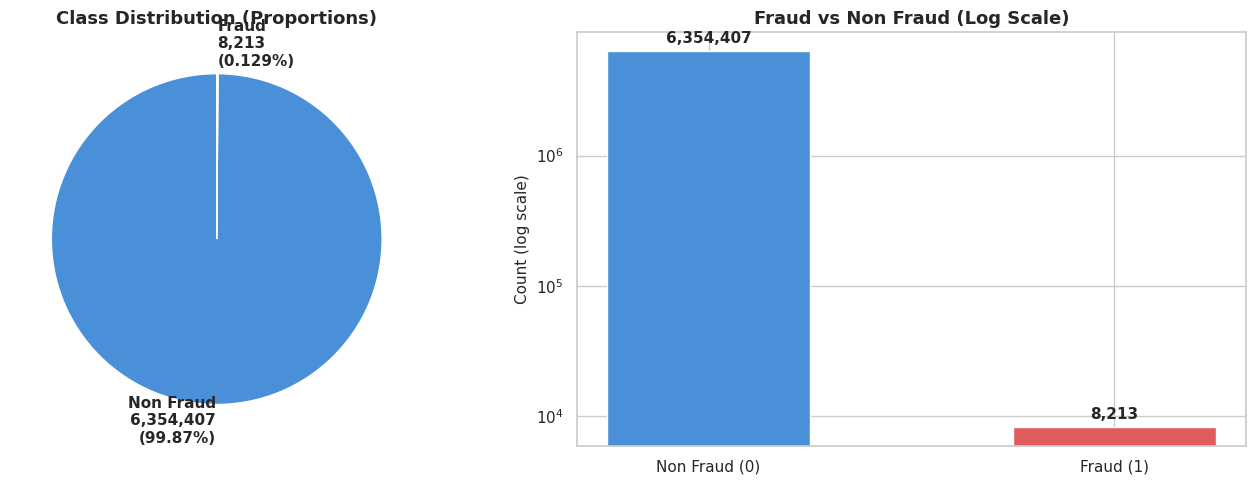

In [12]:
fraud_counts = df['isFraud'].value_counts()
fraud_pct = df['isFraud'].value_counts(normalize=True) * 100

print('Fraud Distribution:')
print(pd.DataFrame({'Count': fraud_counts, 'Percentage': fraud_pct.round(4)}))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Pie chart to show proportions clearly
colors = ['#4A90D9', '#E05B5B']
labels = [f'Non Fraud\n{fraud_counts[0]:,}\n({fraud_pct[0]:.2f}%)',
          f'Fraud\n{fraud_counts[1]:,}\n({fraud_pct[1]:.3f}%)']
explode = (0, 0.08)
axes[0].pie(fraud_counts, labels=labels, colors=colors, explode=explode,
            autopct='', startangle=90, textprops={'fontsize': 11, 'fontweight': 'bold'})
axes[0].set_title('Class Distribution (Proportions)', fontsize=13, fontweight='bold')

# Right: Log-scale bar chart so both bars are visible
bars = axes[1].bar(['Non Fraud (0)', 'Fraud (1)'], fraud_counts.values,
                    color=colors, edgecolor='white', width=0.5)
axes[1].set_yscale('log')
axes[1].set_title('Fraud vs Non Fraud (Log Scale)', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Count (log scale)', fontsize=11)

for bar, count in zip(bars, fraud_counts.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.15,
                 f'{count:,}', ha='center', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.savefig('fig1_class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

The imbalance is pretty extreme. Fraud makes up less than 1% of all transactions which means any model we train will need some kind of resampling or class weighting otherwise it will just learn to always predict non fraud and still get 99% accuracy. This is something we need to keep in mind going forward.

### 5.2 Fraud by Transaction Type
**Research Question 2:** Which transaction types are more likely to involve fraud?

The dataset contains several transaction types, including PAYMENT, TRANSFER, and CASH_OUT. We want to see whether fraud occurs across all types or is concentrated in specific ones. Transactions like TRANSFER or CASH_OUT may be more prone to fraud than regular PAYMENTS.

In [1]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: Fraud counts only (by type) — so the small bars are actually visible
fraud_by_type = df[df['isFraud'] == 1].groupby('type', observed=True).size().reindex(
    df['type'].cat.categories, fill_value=0)
colors_type = ['#4A90D9' if v == 0 else '#E05B5B' for v in fraud_by_type.values]

bars = axes[0].bar(fraud_by_type.index.astype(str), fraud_by_type.values,
                    color=colors_type, edgecolor='white', width=0.55)
axes[0].set_title('Fraud Cases by Transaction Type', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Transaction Type', fontsize=11)
axes[0].set_ylabel('Fraud Count', fontsize=11)
for bar, val in zip(bars, fraud_by_type.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 40,
                 f'{val:,}', ha='center', fontweight='bold', fontsize=10)

# Right: Fraud rate (%) by type — clearly shows which types are riskiest
fraud_rate_by_type = (df.groupby('type', observed=True)['isFraud'].mean() * 100)
colors_rate = ['#E05B5B' if v > 0 else '#4A90D9' for v in fraud_rate_by_type.values]

bars2 = axes[1].bar(fraud_rate_by_type.index.astype(str), fraud_rate_by_type.values,
                     color=colors_rate, edgecolor='white', width=0.55)
axes[1].set_title('Fraud Rate (%) by Transaction Type', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Transaction Type', fontsize=11)
axes[1].set_ylabel('Fraud Rate (%)', fontsize=11)
for bar, val in zip(bars2, fraud_rate_by_type.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f'{val:.2f}%', ha='center', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.savefig('fig2_fraud_by_type.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nFraud rate by type:')
print((df.groupby('type', observed=True)['isFraud'].mean() * 100).round(2).to_string())

NameError: name 'plt' is not defined


The results show that fraudulent activity occurs primarily in **TRANSFER** and **CASH_OUT** transactions.

This pattern is reasonable since these transaction types involve moving funds out of an account, which provides opportunities for fraudulent actors to transfer or withdraw money. In contrast, transaction types such as **PAYMENT** and **CASH_IN** show no fraud cases in this dataset.

### 5.3 Transaction Amount Distribution
**Research Question 3:** Does transaction amount influence the likelihood of fraud?

Fraudulent transactions may involve larger sums of money, as attackers typically attempt to maximize financial gain. Therefore we examine the distribution of transaction amounts and compare fraud and non-fraud cases.

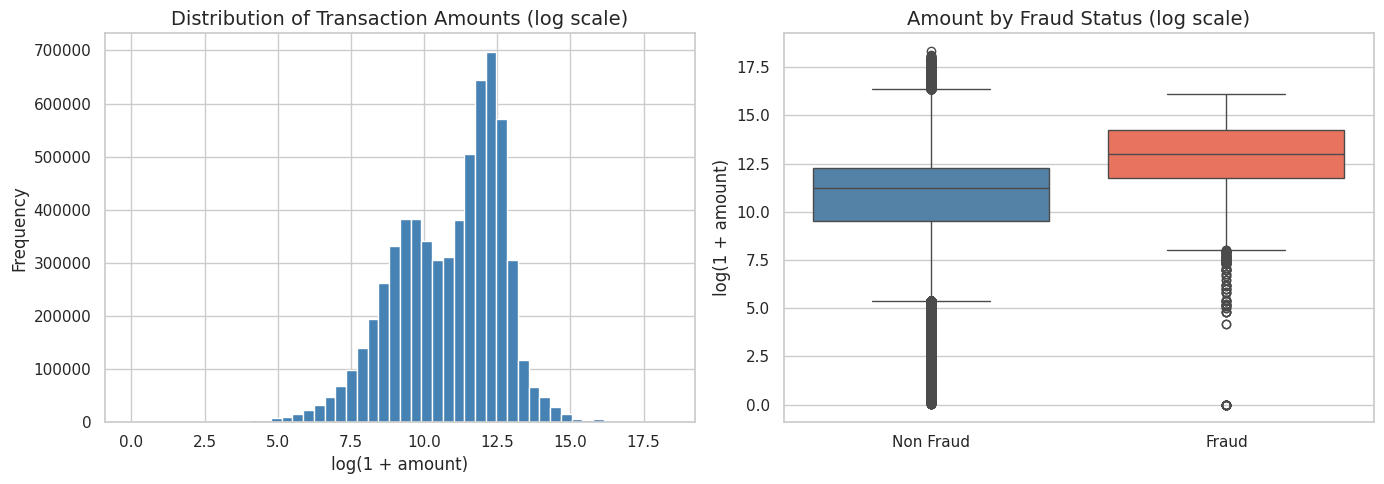

Median amount >> Fraud: 441,423 | Non Fraud: 74,685


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# histogram of all transaction amounts (log scale since they are very skewed)
axes[0].hist(np.log1p(df['amount']), bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Distribution of Transaction Amounts (log scale)')
axes[0].set_xlabel('log(1 + amount)')
axes[0].set_ylabel('Frequency')

# boxplot fraud vs non fraud
df_box = df[['amount', 'isFraud']].copy()
df_box['isFraud'] = df_box['isFraud'].map({0: 'Non Fraud', 1: 'Fraud'})
df_box['log_amount'] = np.log1p(df_box['amount'])

sns.boxplot(data=df_box, x='isFraud', y='log_amount',
            palette={'Non Fraud': 'steelblue', 'Fraud': 'tomato'}, ax=axes[1])
axes[1].set_title('Amount by Fraud Status (log scale)')
axes[1].set_xlabel('')
axes[1].set_ylabel('log(1 + amount)')

plt.tight_layout()
plt.savefig('fig3_amount_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

fraud_amounts = df[df['isFraud'] == 1]['amount']
legit_amounts = df[df['isFraud'] == 0]['amount']
print(f'Median amount >> Fraud: {fraud_amounts.median():,.0f} | Non Fraud: {legit_amounts.median():,.0f}')

Looking at the boxplot fraud transactions tend to involve higher amounts on average. The median fraud amount is noticeably larger than the median for legit transactions. This makes sense since attackers would want to maximize what they steal in each attempt. The overall distribution is heavily right skewed which is why we used log scale.

### 5.4 Balance Discrepancy Analysis
**Research Question 1:** Identifying patterns that distinguish fraud from normal transactions.

For legitimate transactions, the balance after the transaction should closely match the balance before the transaction minus the transferred amount.

However, fraudulent transactions may create inconsistencies in these balances. For this, we created two features:

- `errorBalanceOrig`
- `errorBalanceDest`

These features measure discrepancies between expected and actual balances.

In [15]:
df['errorBalanceOrig'] = df['newbalanceOrig'] - (df['oldbalanceOrg'] - df['amount'])
df['errorBalanceDest'] = df['newbalanceDest'] - (df['oldbalanceDest'] + df['amount'])

print('Mean errorBalanceOrig:')
print(df.groupby('isFraud')['errorBalanceOrig'].mean())
print('\nMean errorBalanceDest:')
print(df.groupby('isFraud')['errorBalanceDest'].mean())

Mean errorBalanceOrig:
isFraud
0    201338.558109
1     10692.325265
Name: errorBalanceOrig, dtype: float64

Mean errorBalanceDest:
isFraud
0    -54692.231734
1   -732509.301069
Name: errorBalanceDest, dtype: float64


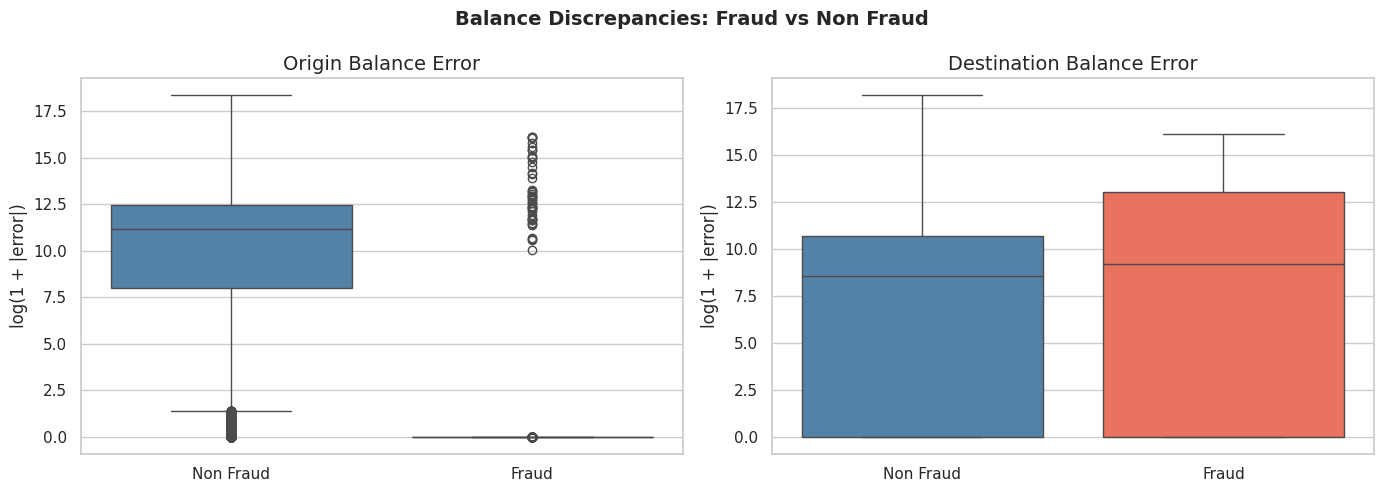

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df_bal = df[['errorBalanceOrig', 'errorBalanceDest', 'isFraud']].copy()
df_bal['isFraud'] = df_bal['isFraud'].map({0: 'Non Fraud', 1: 'Fraud'})
df_bal['log_errorOrig'] = np.log1p(np.abs(df_bal['errorBalanceOrig']))
df_bal['log_errorDest'] = np.log1p(np.abs(df_bal['errorBalanceDest']))

sns.boxplot(data=df_bal, x='isFraud', y='log_errorOrig',
            palette={'Non Fraud': 'steelblue', 'Fraud': 'tomato'}, ax=axes[0])
axes[0].set_title('Origin Balance Error')
axes[0].set_ylabel('log(1 + |error|)')
axes[0].set_xlabel('')

sns.boxplot(data=df_bal, x='isFraud', y='log_errorDest',
            palette={'Non Fraud': 'steelblue', 'Fraud': 'tomato'}, ax=axes[1])
axes[1].set_title('Destination Balance Error')
axes[1].set_ylabel('log(1 + |error|)')
axes[1].set_xlabel('')

plt.suptitle('Balance Discrepancies: Fraud vs Non Fraud', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig4_balance_errors.png', dpi=150, bbox_inches='tight')
plt.show()

The visualizations indicate that fraudulent transactions exhibit significantly larger balance discrepancies compared to legitimate ones.

For non-fraudulent transactions, the errors remain relatively small and clustered around zero. This suggests that these engineered features may serve as useful predictors in future fraud detection models.

### 5.5 Correlation Analysis
**Research Question:** Exploring relationships among numeric features.

A correlation heatmap gives us a quick overview of how the numerical columns relate to each other and to the fraud label. If any feature has a noticeable correlation with `isFraud` that could be useful as a predictor later.

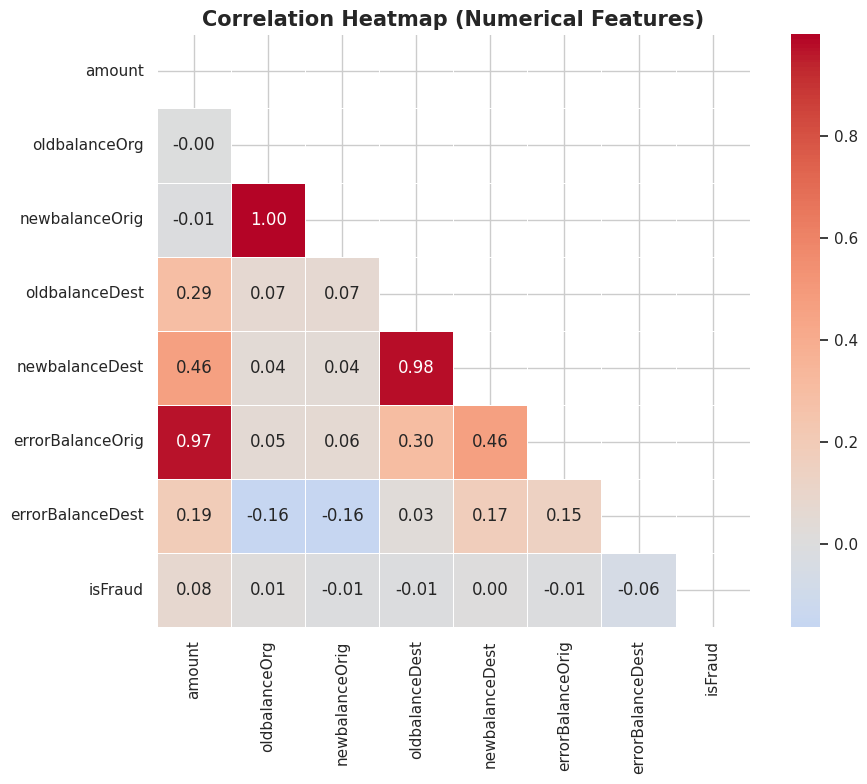


Correlations with isFraud:
amount              0.076688
oldbalanceOrg       0.010154
newbalanceDest      0.000535
oldbalanceDest     -0.005885
newbalanceOrig     -0.008148
errorBalanceOrig   -0.011283
errorBalanceDest   -0.055120
Name: isFraud, dtype: float64


In [17]:
num_cols = ['amount', 'oldbalanceOrg', 'newbalanceOrig',
            'oldbalanceDest', 'newbalanceDest',
            'errorBalanceOrig', 'errorBalanceDest', 'isFraud']

corr_matrix = df[num_cols].corr()

plt.figure(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, mask=mask, square=True, linewidths=0.5)
plt.title('Correlation Heatmap (Numerical Features)', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('fig5_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

# Feature correlations with isFraud
print('\nCorrelations with isFraud:')
print(corr_matrix['isFraud'].drop('isFraud').sort_values(ascending=False))

The correlation analysis shows that most variables do not have strong linear relationships with the fraud label.

This is expected because fraudulent behavior often depends on complex interactions between multiple factors rather than a simple linear relationship. The engineered balance discrepancy features show some association with fraud, reinforcing their potential usefulness for predictive modeling.

## 6. Summary
From our exploratory analysis, several key insights emerged:

- Fraudulent transactions represent a very small proportion of the dataset, indicating strong class imbalance.
- Fraud primarily occurs in **TRANSFER** and **CASH_OUT** transaction types.
- Fraudulent transactions generally involve larger transaction amounts.
- Balance discrepancies between expected and recorded values appear to be strong indicators of fraudulent behavior.

In [18]:
print('EDA Summary')
print('-' * 40)

print(f'\nDataset: {df.shape[0]:,} rows, {df.shape[1]} columns')
print(f'No missing values or duplicates found')

fraud_total = df['isFraud'].sum()
fraud_rate = df['isFraud'].mean() * 100
print(f'\nFraud cases: {fraud_total:,} ({fraud_rate:.3f}% of all transactions)')

print('\nRQ1: What patterns distinguish fraud from normal transactions?')
print('  Balance discrepancies are significantly larger in fraud cases.')
print('  The engineered error features (errorBalanceOrig, errorBalanceDest)')
print('  show a clear separation between fraud and non fraud.')

print('\nRQ2: Which transaction types involve fraud?')
fraud_types = df[df['isFraud'] == 1]['type'].unique()
for t in fraud_types:
    cnt = df[(df['isFraud']==1) & (df['type']==t)].shape[0]
    rate = df[df['type']==t]['isFraud'].mean() * 100
    print(f'  {t}: {cnt:,} fraud cases ({rate:.2f}% fraud rate)')
print('  No fraud found in PAYMENT, CASH_IN, or DEBIT.')

print('\nRQ3: Does amount influence fraud?')
print(f'  Median fraud amount: {df[df["isFraud"]==1]["amount"].median():,.0f}')
print(f'  Median legit amount: {df[df["isFraud"]==0]["amount"].median():,.0f}')
print('  Fraud transactions tend to involve larger amounts.')

print('\nFor modeling we should consider:')
print('  Heavy class imbalance needs resampling or weighted models')
print('  Only TRANSFER and CASH_OUT have fraud so filtering could help')
print('  Balance error features look like strong predictors')

EDA Summary
----------------------------------------

Dataset: 6,362,620 rows, 13 columns
No missing values or duplicates found

Fraud cases: 8,213 (0.129% of all transactions)

RQ1: What patterns distinguish fraud from normal transactions?
  Balance discrepancies are significantly larger in fraud cases.
  The engineered error features (errorBalanceOrig, errorBalanceDest)
  show a clear separation between fraud and non fraud.

RQ2: Which transaction types involve fraud?
  TRANSFER: 4,097 fraud cases (0.77% fraud rate)
  CASH_OUT: 4,116 fraud cases (0.18% fraud rate)
  No fraud found in PAYMENT, CASH_IN, or DEBIT.

RQ3: Does amount influence fraud?
  Median fraud amount: 441,423
  Median legit amount: 74,685
  Fraud transactions tend to involve larger amounts.

For modeling we should consider:
  Heavy class imbalance needs resampling or weighted models
  Only TRANSFER and CASH_OUT have fraud so filtering could help
  Balance error features look like strong predictors


## Saving the Cleaned Dataset
Exporting the cleaned and feature engineered data for the modeling phase.

In [19]:
df.to_csv('fraud_detection_cleaned.csv', index=False)
print('Saved: fraud_detection_cleaned.csv')
print(f'Shape: {df.shape}')
print(f'Columns: {list(df.columns)}')

Saved: fraud_detection_cleaned.csv
Shape: (6362620, 13)
Columns: ['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig', 'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud', 'isFlaggedFraud', 'errorBalanceOrig', 'errorBalanceDest']
